# What drives the price of a car?

![](images/kurt.jpeg)

**OVERVIEW**

In this application, you will explore a dataset from Kaggle. The original dataset contained information on 3 million used cars. The provided dataset contains information on 426K cars to ensure speed of processing.  Your goal is to understand what factors make a car more or less expensive.  As a result of your analysis, you should provide clear recommendations to your client -- a used car dealership -- as to what consumers value in a used car.

### CRISP-DM Framework

<center>
    <img src = images/crisp.png width = 50%/>
</center>


To frame the task, throughout our practical applications, we will refer back to a standard process in industry for data projects called CRISP-DM.  This process provides a framework for working through a data problem.  Your first step in this application will be to read through a brief overview of CRISP-DM [here](https://mo-pcco.s3.us-east-1.amazonaws.com/BH-PCMLAI/module_11/readings_starter.zip).  After reading the overview, answer the questions below.

### Business Understanding

From a business perspective, we are tasked with identifying key drivers for used car prices.  In the CRISP-DM overview, we are asked to convert this business framing to a data problem definition.  Using a few sentences, reframe the task as a data task with the appropriate technical vocabulary. 

The business problem can be reframed as a supervised machine learning regression task. Using historical data on used cars, the objective is to identify the factors that most influence vehicle prices and build predictive models to estimate a car's selling price. This involves cleaning and exploring the data, selecting relevant features, training and evaluating multiple regression models, and interpreting the results to determine which vehicle characteristics have the greatest impact on price. The findings will help the dealership make more informed inventory and pricing decisions.

### Data Understanding

After considering the business understanding, we want to get familiar with our data.  Write down some steps that you would take to get to know the dataset and identify any quality issues within.  Take time to get to know the dataset and explore what information it contains and how this could be used to inform your business understanding.

In [1]:
import statsmodels.api as sm
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from warnings import filterwarnings 
filterwarnings('ignore')
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [2]:
data = pd.read_csv('data/vehicles.csv')

In [3]:
data.head()

,id,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,VIN,drive,size,type,paint_color,state
0,7222695916,prescott,6000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,az
1,7218891961,fayetteville,11900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ar
2,7221797935,florida keys,21000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,fl
3,7222270760,worcester / central MA,1500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ma
4,7210384030,greensboro,4900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nc


The first step is to examine the number of observations and features, identify the data types of each variable, and review summary statistics for numerical variables such as price, year, and odometer readings. For categorical variables (e.g., manufacturer, fuel type, transmission, and condition), the distribution of categories should be examined.

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 426880 entries, 0 to 426879
Data columns (total 18 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            426880 non-null  int64  
 1   region        426880 non-null  object 
 2   price         426880 non-null  int64  
 3   year          425675 non-null  float64
 4   manufacturer  409234 non-null  object 
 5   model         421603 non-null  object 
 6   condition     252776 non-null  object 
 7   cylinders     249202 non-null  object 
 8   fuel          423867 non-null  object 
 9   odometer      422480 non-null  float64
 10  title_status  418638 non-null  object 
 11  transmission  424324 non-null  object 
 12  VIN           265838 non-null  object 
 13  drive         296313 non-null  object 
 14  size          120519 non-null  object 
 15  type          334022 non-null  object 
 16  paint_color   296677 non-null  object 
 17  state         426880 non-null  object 
dtypes: f

In [5]:
## Finding percentages of missing values to decide if I should drop, keep or fill missing values.
missing = (
    data.isnull()
        .sum()
        .to_frame('Missing Values')
)

missing['Percent Missing'] = (
    missing['Missing Values'] / len(data) * 100
).round(2)

missing.sort_values('Percent Missing', ascending=False)

,Missing Values,Percent Missing
size,306361,71.77
cylinders,177678,41.62
condition,174104,40.79
VIN,161042,37.73
drive,130567,30.59
paint_color,130203,30.50
type,92858,21.75
manufacturer,17646,4.13
title_status,8242,1.93
model,5277,1.24


In [6]:
## Data Preparation on Duplicated Values
data.duplicated().sum()

np.int64(0)

In [7]:
### Data Preparation on Missing Values

## Dropping columns that are not useful 
# size (72% missing) & VIN (unique idenitifer, no predictive value)
data = data.drop(columns=['size','VIN'])

## Drop rows with missing values in selected columns
# These columns have relatively low percentages of missing values.
data = data.dropna(subset=[
    'title_status',
    'model',
    'odometer',
    'fuel',
    'transmission',
    'year'
])

## Fill missing categorical values with "Unknown" to preserve as much features for multiple regression models
cat_cols = [
    'manufacturer',
    'condition',
    'cylinders',
    'drive',
    'type',
    'paint_color'
]

for col in cat_cols:
    data[col] = data[col].fillna('Unknown')

In [8]:
# Check
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 405594 entries, 27 to 426879
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            405594 non-null  int64  
 1   region        405594 non-null  object 
 2   price         405594 non-null  int64  
 3   year          405594 non-null  float64
 4   manufacturer  405594 non-null  object 
 5   model         405594 non-null  object 
 6   condition     405594 non-null  object 
 7   cylinders     405594 non-null  object 
 8   fuel          405594 non-null  object 
 9   odometer      405594 non-null  float64
 10  title_status  405594 non-null  object 
 11  transmission  405594 non-null  object 
 12  drive         405594 non-null  object 
 13  type          405594 non-null  object 
 14  paint_color   405594 non-null  object 
 15  state         405594 non-null  object 
dtypes: float64(2), int64(2), object(12)
memory usage: 52.6+ MB


In [9]:
##


In [10]:
## Check for inconsistent formatting
for col in data.select_dtypes(include='object'):
    print(f"\n{col}")
    print(data[col].value_counts().head(20))


region
region
columbus                   3482
jacksonville               3306
grand rapids               2945
new hampshire              2939
reno / tahoe               2929
south jersey               2924
baltimore                  2922
tulsa                      2919
pittsburgh                 2912
rochester                  2911
maine                      2909
boise                      2905
houston                    2903
long island                2899
milwaukee                  2897
cleveland                  2894
spokane / coeur d'alene    2887
boston                     2879
new york city              2874
sarasota-bradenton         2873
Name: count, dtype: int64

manufacturer
manufacturer
ford             67811
chevrolet        52326
toyota           32509
honda            20407
jeep             18150
nissan           18053
ram              16770
Unknown          15990
gmc              15941
bmw              14224
dodge            12864
mercedes-benz    11195
hyundai         

In [11]:
## Check data types
data.dtypes

id                int64
region           object
price             int64
year            float64
manufacturer     object
model            object
condition        object
cylinders        object
fuel             object
odometer        float64
title_status     object
transmission     object
drive            object
type             object
paint_color      object
state            object
dtype: object

In [12]:
# Convert 'year' from float to int
data['year'] = data['year'].astype(int)

In [13]:
## Check outliers / impossible values
data.describe()

,id,price,year,odometer
count,4.055940e+05,4.055940e+05,405594.000000,4.055940e+05
mean,7.311497e+09,6.276877e+04,2011.317108,9.784640e+04
std,4.383323e+06,1.122406e+07,9.211517,2.064874e+05
min,7.301583e+09,0.000000e+00,1900.000000,0.000000e+00
25%,7.308146e+09,5.994000e+03,2008.000000,3.795550e+04
50%,7.312641e+09,1.399500e+04,2013.000000,8.568900e+04
75%,7.315255e+09,2.659000e+04,2017.000000,1.338630e+05
max,7.317101e+09,3.736929e+09,2022.000000,1.000000e+07


In [14]:
# Min for price is at 0. Keeping them would bias my regression model downward because it would try to learn why some cars are "worth" $0.
# Some cars are priced at $1 which is not realistic either and will not reflect market value. We will use a minimum reasonable selling price.
data = data[data['price'] >= 500]

# Max for price is at 3.7 billion. That is unrealistic. Since the assignment is about typical used-car pricing rather than rare \
# vehicles, we will use a maximum of $300,000
data = data[data['price'] <= 300000]

# Max for odometer is 10,000 miles which is essentially impossible, could be a placeholder value
# We will use a maximum of 500,000 miles which is already extremely high
data = data[data['odometer'] < 500000]

In [15]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 366434 entries, 27 to 426879
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            366434 non-null  int64  
 1   region        366434 non-null  object 
 2   price         366434 non-null  int64  
 3   year          366434 non-null  int64  
 4   manufacturer  366434 non-null  object 
 5   model         366434 non-null  object 
 6   condition     366434 non-null  object 
 7   cylinders     366434 non-null  object 
 8   fuel          366434 non-null  object 
 9   odometer      366434 non-null  float64
 10  title_status  366434 non-null  object 
 11  transmission  366434 non-null  object 
 12  drive         366434 non-null  object 
 13  type          366434 non-null  object 
 14  paint_color   366434 non-null  object 
 15  state         366434 non-null  object 
dtypes: float64(1), int64(3), object(12)
memory usage: 47.5+ MB


In [16]:
## insert summary

### Data Preparation

After our initial exploration and fine-tuning of the business understanding, it is time to construct our final dataset prior to modeling.  Here, we want to make sure to handle any integrity issues and cleaning, the engineering of new features, any transformations that we believe should happen (scaling, logarithms, normalization, etc.), and general preparation for modeling with `sklearn`. 

In [17]:
# Both state and region describe vehicle location. Since region is a more granular subdivision of state and introduces 404 categories, only state was retained to reduce dimensionality while preserving geographic information.

In [18]:
# Create age of the car from Year
listing_year = data['year'].max()
data['age'] = listing_year - data['year']

data[['year','age']].head()

,year,age
27,2014,8
28,2010,12
29,2020,2
30,2017,5
31,2013,9


In [19]:
# Convert data['condition'] to ordinal numbers (letting "Unknown" become NaN)
condition_map = {
    'salvage': 0,
    'fair': 1,
    'good': 2,
    'excellent': 3,
    'like new': 4,
    'new': 5
}

data['condition'] = data['condition'].map(condition_map)

In [20]:
# Convert data['cylinders'] to numeric (letting "Unknown" and "other" become NaN)
data['cylinders'] = (
    data['cylinders']
    .str.extract(r'(\d+)')
    .astype(float)
)

In [21]:
#Drop columns
data.drop(columns=['year','id','model','region'], inplace=True)

#### Build preprocessing pipeline

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

In [23]:
X = data.drop(columns='price')
y = data['price']

In [24]:
numeric_features = ['age', 'odometer', 'condition', 'cylinders']

categorical_features = [
    'manufacturer',
    'fuel',
    'title_status',
    'transmission',
    'drive',
    'type',
    'paint_color',
    'state'
]

In [25]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,random_state=42)

In [26]:
#Numeric Pipeline
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

#Categorical Pipeline
categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

#Combine into one pipeline
preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

### Modeling

With your (almost?) final dataset in hand, it is now time to build some models.  Here, you should build a number of different regression models with the price as the target.  In building your models, you should explore different parameters and be sure to cross-validate your findings.

In [27]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score

#### First Model : Linear Regression

In [28]:
linear_model = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

linear_model.fit(X_train, y_train)
linear_y_pred = linear_model.predict(X_test)

In [29]:
linear_mae = mean_absolute_error(y_test, linear_y_pred)
linear_rmse = mean_squared_error(y_test, linear_y_pred) ** 0.5
linear_r2 = r2_score(y_test, linear_y_pred)

print("MAE:", linear_mae)
print("RMSE:", linear_rmse)
print("R²:", linear_r2)

MAE: 6280.016794006716
RMSE: 9811.504207565293
R²: 0.5771049500388654


The baseline Linear Regression model provides a reasonable starting point for predicting used car prices. It explains approximately 57.7% of the variation in vehicle prices (R² = 0.577). On average, the model's predictions differ from the actual selling price by approximately $6,280 (MAE), with larger errors observed for some vehicles (RMSE = 9,812). These results suggest that while the selected features capture important pricing factors, additional modeling techniques or feature improvements may further improve predictive accuracy.

#### Second model - Ridge Regression

In [30]:
from sklearn.linear_model import Ridge

ridge_model = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', Ridge())
])

ridge_model.fit(X_train, y_train)
ridge_y_pred = ridge_model.predict(X_test)

In [31]:
ridge_mae = mean_absolute_error(y_test, ridge_y_pred)
ridge_rmse = mean_squared_error(y_test, ridge_y_pred) ** 0.5
ridge_r2 = r2_score(y_test, ridge_y_pred)

print("MAE:", ridge_mae)
print("RMSE:", ridge_rmse)
print("R²:", ridge_r2)

MAE: 6280.241918533072
RMSE: 9811.962697596631
R²: 0.5770654254785319


In [32]:
#Creating a dataframe for comparison
results = pd.DataFrame(columns=['Best Parameters','MAE', 'RMSE', 'R²'])
results.loc['Linear Regression'] = ['-',linear_mae, linear_rmse, linear_r2]
results.loc['Ridge Regression'] = ['Default',ridge_mae, ridge_rmse, ridge_r2]

results.round(2)

,Best Parameters,MAE,RMSE,R²
Linear Regression,-,6280.02,9811.50,0.58
Ridge Regression,Default,6280.24,9811.96,0.58


#### Evaluation of Model 1 - Linear Model Cross Validation

In [33]:
from sklearn.model_selection import cross_validate

cv_results = cross_validate(
    linear_model,
    X,
    y,
    cv=5,
    scoring={
        'mae': 'neg_mean_absolute_error',
        'rmse': 'neg_root_mean_squared_error',
        'r2': 'r2'
    }
)

cv_mae = -cv_results['test_mae'].mean()
cv_rmse = -cv_results['test_rmse'].mean()
cv_r2 = cv_results['test_r2'].mean()

In [34]:
results.loc['Linear Regression (CV)'] = [
    '5-Fold CV',
    cv_mae,
    cv_rmse,
    cv_r2
]

results.round(2)

,Best Parameters,MAE,RMSE,R²
Linear Regression,-,6280.02,9811.50,0.58
Ridge Regression,Default,6280.24,9811.96,0.58
Linear Regression (CV),5-Fold CV,6351.71,9905.72,0.56


#### Evaluation of Model 2 - Ridge Regression & GridSearchCV

In [35]:
param_grid = {
    'regressor__alpha': [0.01, 0.1, 1, 10, 100]
}

from sklearn.model_selection import GridSearchCV

ridge_grid = GridSearchCV(
    estimator=ridge_model,
    param_grid=param_grid,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

ridge_grid.fit(X_train, y_train)
ridge_grid.best_params_

{'regressor__alpha': 0.01}

In [36]:
-ridge_grid.best_score_

np.float64(9779.662323074368)

In [37]:
best_ridge = ridge_grid.best_estimator_
ridge_best_pred = best_ridge.predict(X_test)

ridge_best_mae = mean_absolute_error(y_test, ridge_best_pred)
ridge_best_rmse = mean_squared_error(y_test, ridge_best_pred) ** 0.5
ridge_best_r2 = r2_score(y_test, ridge_best_pred)

In [38]:
results.loc['Ridge Regression (GridSearchCV)'] = [
    f"alpha = {ridge_grid.best_params_['regressor__alpha']}",
    ridge_best_mae,
    ridge_best_rmse,
    ridge_best_r2
]

results.round(2)


,Best Parameters,MAE,RMSE,R²
Linear Regression,-,6280.02,9811.50,0.58
Ridge Regression,Default,6280.24,9811.96,0.58
Linear Regression (CV),5-Fold CV,6351.71,9905.72,0.56
Ridge Regression (GridSearchCV),alpha = 0.01,6280.16,9811.73,0.58


Ridge Regression with hyperparameter tuning (GridSearchCV) selected α = 0.001. However, performance was nearly identical to ordinary Linear Regression, suggesting that regularization provided little additional benefit for this dataset.

#### Model 4 - Lasso Regression

In [39]:
from sklearn.linear_model import Lasso

lasso_model = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor',Lasso(random_state=42))
])

lasso_params = {
    'regressor__alpha': [0.001, 0.01, 0.1, 1, 10]
}

lasso_grid = GridSearchCV(
    lasso_model,
    lasso_params,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

lasso_grid.fit(X_train, y_train)
lasso_grid.best_params_

{'regressor__alpha': 0.01}

In [40]:
-lasso_grid.best_score_

np.float64(9779.440994905583)

In [41]:
best_lasso = lasso_grid.best_estimator_

lasso_pred = best_lasso.predict(X_test)

lasso_mae = mean_absolute_error(y_test, lasso_pred)
lasso_rmse = mean_squared_error(y_test, lasso_pred) ** 0.5
lasso_r2 = r2_score(y_test, lasso_pred)

results.loc['Lasso Regression (GridSearchCV)'] = [
    f"alpha = {lasso_grid.best_params_['regressor__alpha']}",
    lasso_mae,
    lasso_rmse,
    lasso_r2
]

results.round(2)

,Best Parameters,MAE,RMSE,R²
Linear Regression,-,6280.02,9811.50,0.58
Ridge Regression,Default,6280.24,9811.96,0.58
Linear Regression (CV),5-Fold CV,6351.71,9905.72,0.56
Ridge Regression (GridSearchCV),alpha = 0.01,6280.16,9811.73,0.58
Lasso Regression (GridSearchCV),alpha = 0.01,6279.98,9811.52,0.58


#### __Findings__
We compared Linear Regression, Ridge Regression, and Lasso Regression. All three achieved nearly identical performance, suggesting that regularization did not substantially improve predictive accuracy. Therefore, __Linear Regression__ is selected as the final model because it provides comparable performance while remaining the easiest model to interpret.


In [42]:
## Get feature names

# Best linear model
model = linear_model

# Get the fitted preprocessor
preprocessor_fitted = model.named_steps['preprocessor']

# Numeric feature names
numeric_names = numeric_features

# One-hot encoded feature names
categorical_names = preprocessor_fitted.named_transformers_['cat'] \
    .named_steps['encoder'] \
    .get_feature_names_out(categorical_features)

# Combine them
feature_names = list(numeric_names) + list(categorical_names)

In [43]:
# Extract coefficients
coefficients = model.named_steps['regressor'].coef_

coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
})

In [44]:
# Largest Positive
coef_df.sort_values('Coefficient', ascending=False).head(10)

,Feature,Coefficient
16,manufacturer_ferrari,95731.921746
7,manufacturer_aston-martin,19156.673371
42,manufacturer_tesla,14355.403826
46,fuel_diesel,12271.260117
37,manufacturer_porsche,9036.702838
14,manufacturer_datsun,6965.350213
52,title_status_lien,4228.684935
51,title_status_clean,3872.974723
135,state_ut,3430.812324
138,state_wa,3424.298355


### Evaluation

With some modeling accomplished, we aim to reflect on what we identify as a high-quality model and what we are able to learn from this.  We should review our business objective and explore how well we can provide meaningful insight into drivers of used car prices.  Your goal now is to distill your findings and determine whether the earlier phases need revisitation and adjustment or if you have information of value to bring back to your client.

#### Which model should be choosen?

In [45]:
results.round(2)

,Best Parameters,MAE,RMSE,R²
Linear Regression,-,6280.02,9811.50,0.58
Ridge Regression,Default,6280.24,9811.96,0.58
Linear Regression (CV),5-Fold CV,6351.71,9905.72,0.56
Ridge Regression (GridSearchCV),alpha = 0.01,6280.16,9811.73,0.58
Lasso Regression (GridSearchCV),alpha = 0.01,6279.98,9811.52,0.58


Linear Regression, Ridge Regression, and Lasso Regression produced very similar performance (R² ≈ 0.58). Since Ridge and Lasso did not provide a meaningful improvement over Linear Regression, the Linear Regression model was selected because it offers comparable predictive performance while being the most interpretable.

#### __What did the model teach us?__

#### Continous Variables

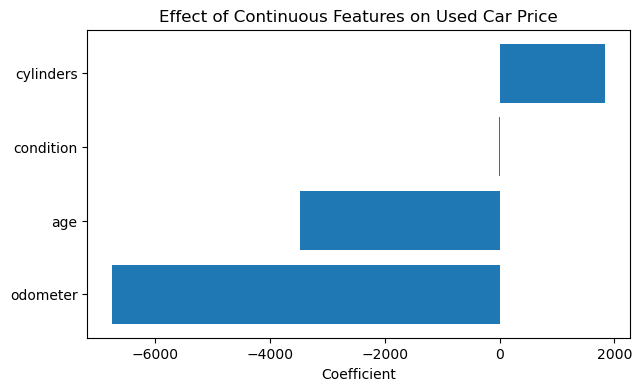

In [46]:
continuous_coef = coef_df[
    coef_df['Feature'].isin(['age', 'odometer', 'condition', 'cylinders'])
].copy()

continuous_coef = continuous_coef.sort_values('Coefficient')

plt.figure(figsize=(7,4))
plt.barh(continuous_coef['Feature'],
         continuous_coef['Coefficient'])

plt.title('Effect of Continuous Features on Used Car Price')
plt.xlabel('Coefficient')
plt.show()

This graph shows the effect of the continuous vehicle characteristics on predicted selling price.

- Odometer has the strongest negative coefficient, suggesting that vehicles with higher mileage generally sell for lower prices.
- Age also has a negative coefficient, indicating that vehicle depreciation over time has a substantial impact on resale value.
- Condition has a positive coefficient, meaning that better-maintained vehicles command higher prices.
- Cylinders has a positive relationship with price, suggesting that vehicles with larger engines tend to have higher resale values.

#### Categorical Variables [Manufacturer]

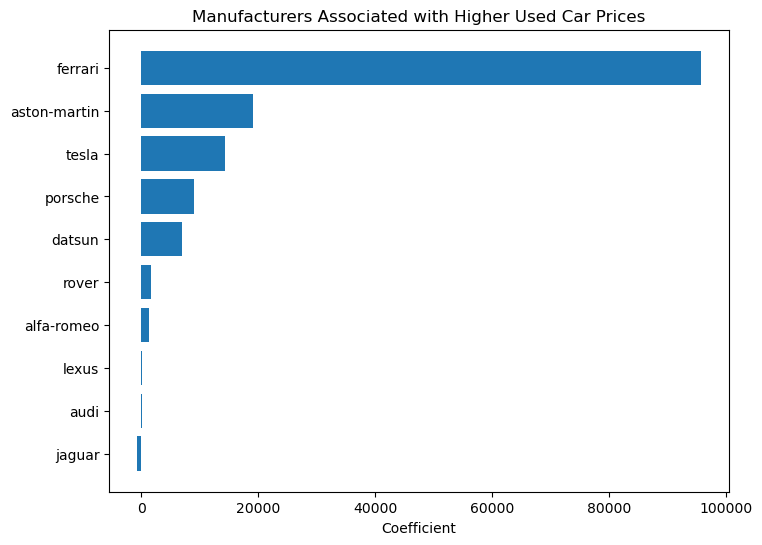

In [47]:
manufacturer_coef = coef_df[
    coef_df['Feature'].str.startswith('manufacturer_')
].copy()

manufacturer_coef['Feature'] = (
    manufacturer_coef['Feature']
    .str.replace('manufacturer_', '', regex=False)
)

manufacturer_coef = manufacturer_coef.sort_values(
    'Coefficient',
    ascending=False
)

top10 = manufacturer_coef.head(10)

plt.figure(figsize=(8,6))
plt.barh(top10['Feature'], top10['Coefficient'])
plt.gca().invert_yaxis()

plt.title('Manufacturers Associated with Higher Used Car Prices')
plt.xlabel('Coefficient')
plt.show()

The model indicates that luxury manufacturers such as Ferrari, Aston Martin, Tesla, and Porsche are associated with substantially higher resale values than the baseline manufacturer.
This suggests that brand reputation and consumer demand remain important drivers of used car prices.

#### Categorical Variables [Fuel, Drive, Type, Title Status]

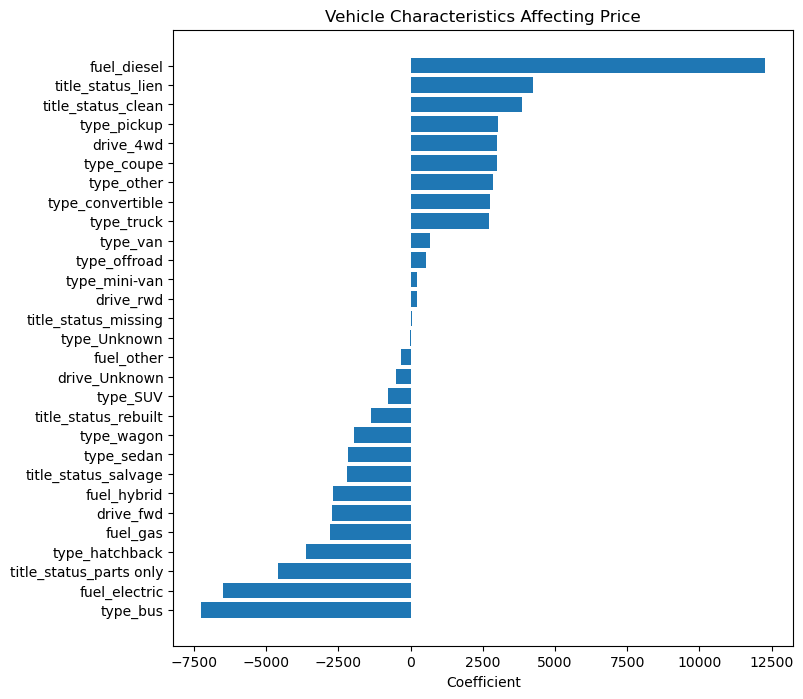

In [48]:
vehicle_coef = coef_df[
    coef_df['Feature'].str.startswith(
        ('fuel_',
         'drive_',
         'type_',
         'title_status_')
    )
].copy()

vehicle_coef = vehicle_coef.sort_values(
    'Coefficient'
)

plt.figure(figsize=(8,8))
plt.barh(vehicle_coef['Feature'],
         vehicle_coef['Coefficient'])

plt.title('Vehicle Characteristics Affecting Price')
plt.xlabel('Coefficient')
plt.show()

Vehicle characteristics also influence resale value.

The model suggests that:
- Diesel vehicles tend to command higher prices.
- Four-wheel-drive vehicles have a price premium.
- Pickup trucks generally retain more value.
- Vehicles with parts-only or salvage titles experience substantial reductions in value.

These findings indicate that both vehicle functionality and legal title status influence consumer willingness to pay.

#### Relationships between ***Age vs Price*** & ***Odometer vs Price***

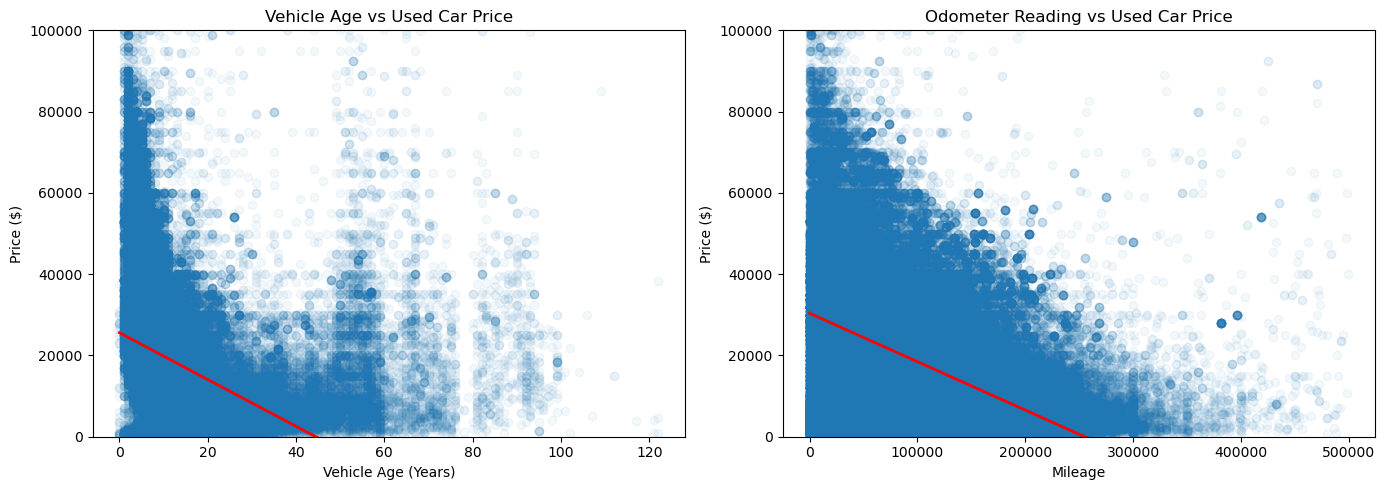

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Age vs Price
axes[0].scatter(
    data['age'],
    data['price'],
    alpha=0.05
)

# Fit regression line
m, b = np.polyfit(data['age'], data['price'], 1)

x = np.linspace(data['age'].min(), data['age'].max(), 100)
axes[0].plot(x, m*x + b, color='red', linewidth=2)

axes[0].set_title('Vehicle Age vs Used Car Price')
axes[0].set_xlabel('Vehicle Age (Years)')
axes[0].set_ylabel('Price ($)')
axes[0].set_ylim(0,100000)

# Odometer vs Price
axes[1].scatter(
    data['odometer'],
    data['price'],
    alpha=0.05
)

m, b = np.polyfit(data['odometer'], data['price'], 1)

x = np.linspace(data['odometer'].min(), data['odometer'].max(), 100)
axes[1].plot(x, m*x + b, color='red', linewidth=2)

axes[1].set_title('Odometer Reading vs Used Car Price')
axes[1].set_xlabel('Mileage')
axes[1].set_ylabel('Price ($)')
axes[1].set_ylim(0,100000)

plt.tight_layout()
plt.show()

The scatter plots visually support the regression model.
Both age and odometer exhibit a clear negative relationship with price, confirming that older vehicles and those with higher mileage generally have lower resale values. Although there is considerable variability—indicating that factors such as manufacturer, condition, and vehicle type also influence price—the overall downward trend is consistent with the regression coefficients.

#### Boxplots of Price Distribution Across Key Vehicle Characteristics

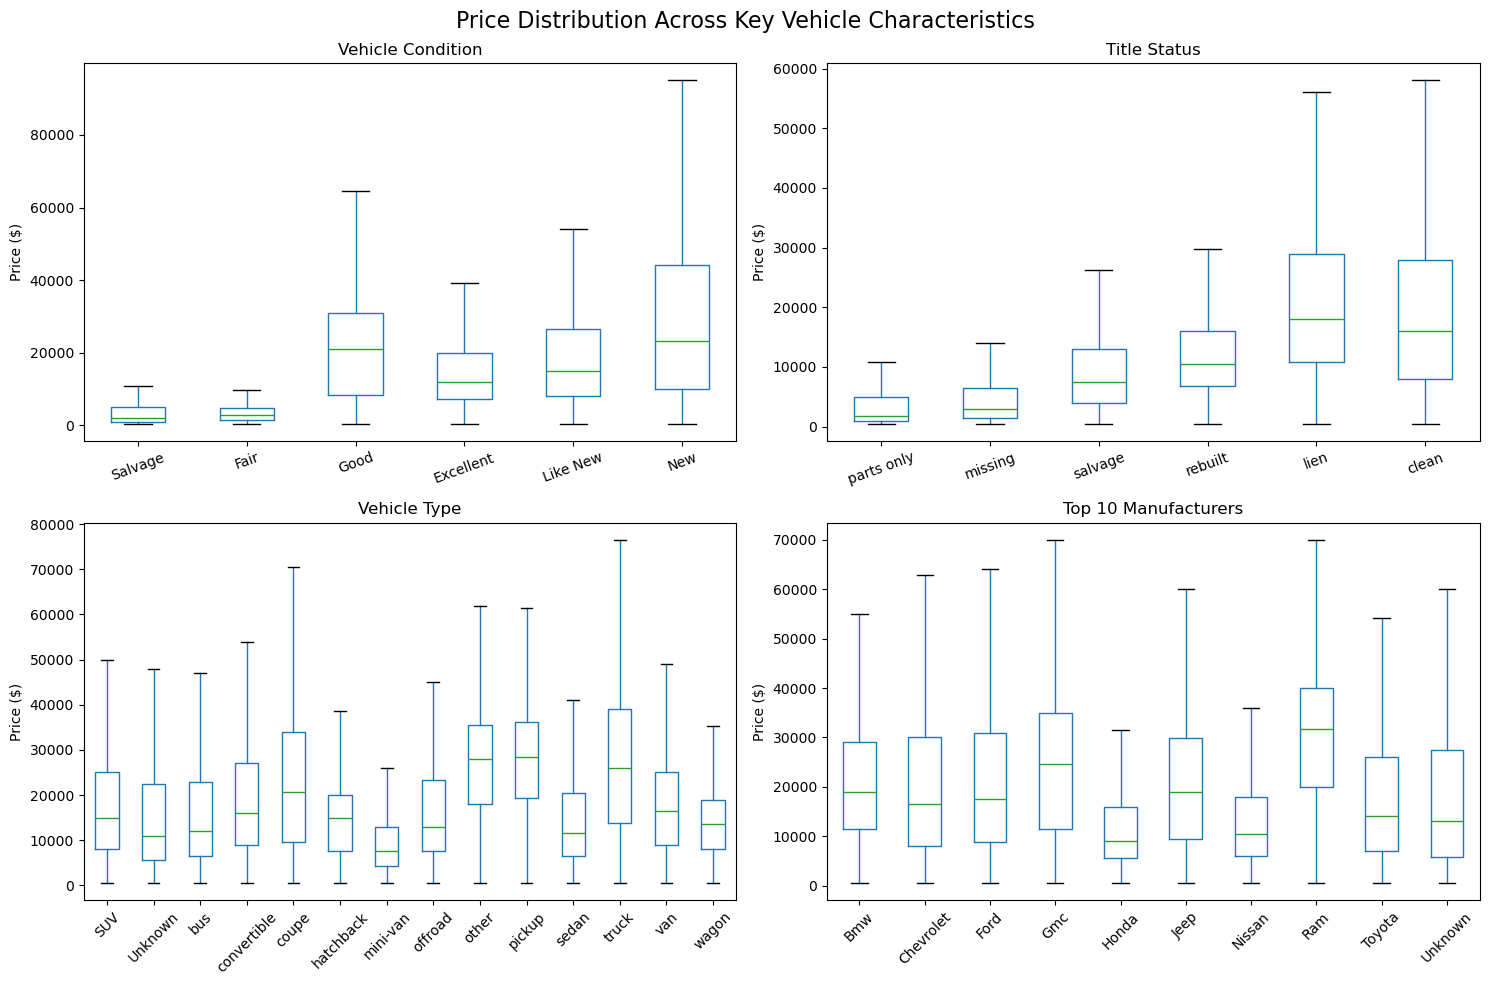

In [50]:
##CleanUp for Plotting
# Top 10 Manufacturers
top10_manufacturers = (
    data['manufacturer']
    .value_counts()
    .head(10)
    .index
)

manufacturer_subset = data[
    data['manufacturer'].isin(top10_manufacturers)
].copy()

# Capitalize manufacturer names
manufacturer_subset['manufacturer'] = (
    manufacturer_subset['manufacturer']
    .str.title()
)

# Create plotting dataframe
plot_data = data.copy()

# Convert condition back to labels
condition_labels = {
    0: 'Salvage',
    1: 'Fair',
    2: 'Good',
    3: 'Excellent',
    4: 'Like New',
    5: 'New'
}

plot_data['condition'] = plot_data['condition'].map(condition_labels)

# Desired plotting order
condition_order = [
    'Salvage',
    'Fair',
    'Good',
    'Excellent',
    'Like New',
    'New'
]

title_order = [
    'parts only',
    'missing',
    'salvage',
    'rebuilt',
    'lien',
    'clean'
]

# Convert to ordered categorical
plot_data['condition'] = pd.Categorical(
    plot_data['condition'],
    categories=condition_order,
    ordered=True
)

plot_data['title_status'] = pd.Categorical(
    plot_data['title_status'],
    categories=title_order,
    ordered=True
)

# -----------------------------
## Plot Boxplots
fig, axes = plt.subplots(2, 2, figsize=(15,10))

# Condition
plot_data.boxplot(
    column='price',
    by='condition',
    ax=axes[0,0],
    grid=False,
    showfliers=False
)

axes[0,0].set_title('Vehicle Condition')
axes[0,0].set_xlabel('')
axes[0,0].set_ylabel('Price ($)')
axes[0,0].tick_params(axis='x', rotation=20)

# Title Status
plot_data.boxplot(
    column='price',
    by='title_status',
    ax=axes[0,1],
    grid=False,
    showfliers=False
)

axes[0,1].set_title('Title Status')
axes[0,1].set_xlabel('')
axes[0,1].set_ylabel('Price ($)')
axes[0,1].tick_params(axis='x', rotation=20)

# Vehicle Type
plot_data.boxplot(
    column='price',
    by='type',
    ax=axes[1,0],
    grid=False,
    showfliers=False
)

axes[1,0].set_title('Vehicle Type')
axes[1,0].set_xlabel('')
axes[1,0].set_ylabel('Price ($)')
axes[1,0].tick_params(axis='x', rotation=45)

# Top 10 Manufacturers
manufacturer_subset.boxplot(
    column='price',
    by='manufacturer',
    ax=axes[1,1],
    grid=False,
    showfliers=False
)

axes[1,1].set_title('Top 10 Manufacturers')
axes[1,1].set_xlabel('')
axes[1,1].set_ylabel('Price ($)')
axes[1,1].tick_params(axis='x', rotation=45)

plt.suptitle(
    'Price Distribution Across Key Vehicle Characteristics',
    fontsize=16
)

plt.tight_layout()
plt.show()

1. __Vehicle Condition__
    * New vehicles have the highest median price.
    * Good, Excellent, Like New and New are much higher than Fair and Salvage.
    * Fair and Salvage have the lowest median prices.
    * New vehicles also show the widest spread, indicating a broader range of selling prices.
    
    Vehicle condition appears to be an important determinant of resale value. As expected, vehicles in better condition generally command higher median prices. New vehicles have the highest median selling price, while Fair and Salvage vehicles have substantially lower prices. This trend supports the positive coefficient observed for the condition variable in the regression model.

2. __Title Status__
    * Parts Only has the lowest prices.
    * Missing titles are also low.
    * Salvage is higher than Parts Only but still relatively low.
    * Rebuilt sits in the middle.
    * Clean and Lien have the highest median prices.
    
    Title status is strongly associated with resale value. Vehicles with clean titles generally achieve the highest prices, whereas vehicles sold for parts, with missing titles, or salvage titles tend to have substantially lower prices. Although vehicles with liens exhibit a slightly higher median price than clean-title vehicles in this dataset, this may reflect differences in vehicle characteristics rather than the presence of a lien itself.

3. __Vehicle Type__
    Highest medians appear to be:
    * Pickup
    * Other
    * Truck
    * Coupe
    
    Lowest:
    * Mini-van
    * Bus
    * Sedan
    
    Vehicle type is associated with considerable differences in resale value. Pickup trucks, trucks, and coupes generally have higher median prices, while buses, minivans, and sedans tend to sell for less. This finding aligns with the regression model, where certain vehicle types were associated with positive price premiums.

4. __Top Manufacturers__
    Highest median:
    * Ram
    * GMC
    * BMW
    * Jeep
    
    Lower:
    * Honda
    * Nissan
    
    Toyota is somewhere in the middle. 

    Manufacturer also plays a significant role in determining resale value. Among the ten most common manufacturers, Ram, GMC, BMW, and Jeep exhibit the highest median prices, while Honda and Nissan have comparatively lower median values. These differences suggest that brand reputation, vehicle segment, and market demand contribute meaningfully to used car pricing.

Overall, these visualizations reinforce the findings from the regression model. Better vehicle condition, clean titles, certain vehicle types (particularly trucks and pickups), and specific manufacturers are consistently associated with higher selling prices. Conversely, salvage vehicles, parts-only titles, and poorer vehicle conditions are associated with substantially lower prices. These descriptive patterns support the model’s conclusion that both vehicle characteristics and brand-related factors are important drivers of used car prices.

In summary, among the models evaluated, Linear Regression was selected as the final model because Ridge and Lasso regularization did not produce meaningful improvements in predictive performance. The final model achieved an R² of approximately 0.58, indicating that it explains about 58% of the variation in used car prices. Analysis of the model coefficients and exploratory visualizations suggests that vehicle age, mileage, manufacturer, condition, title status, and vehicle type are among the most important factors associated with resale value. Although the model performs reasonably well, additional variables such as accident history, maintenance records, optional features, and local market conditions may further improve prediction accuracy.

#### Did the model achieve the business objective?

The model identified vehicle age and odometer reading as two of the strongest negative predictors of price, indicating that older, higher-mileage vehicles tend to sell for less.
Luxury manufacturers such as Ferrari, Aston Martin, Porsche, and Tesla were associated with higher predicted selling prices.
Pickup trucks, four-wheel drive, diesel engines, and vehicles with more cylinders were also positively associated with price.
Conversely, vehicles with parts-only titles and certain manufacturers were associated with lower predicted prices.

### Deployment

Now that we've settled on our models and findings, it is time to deliver the information to the client.  You should organize your work as a basic report that details your primary findings.  Keep in mind that your audience is a group of used car dealers interested in fine-tuning their inventory.

__Executive Summary__

The developed Linear Regression model provides a practical tool for understanding the factors that influence used car prices. While the model explains approximately 58% of the variation in vehicle prices, it successfully identifies several key characteristics that consistently influence resale value. Rather than replacing human judgment, the model should be viewed as a decision-support system that assists dealerships in pricing vehicles more consistently, identifying profitable inventory opportunities, and improving purchasing decisions.

__1. Inventory Acquisition Strategy__

One of the most valuable applications of this model is assisting dealerships when purchasing vehicles from auctions, trade-ins, or wholesale suppliers.

Based on the model findings, dealerships should prioritize acquiring vehicles with:

* Lower vehicle age
* Lower mileage
* Good to excellent condition
* Clean titles
* Manufacturers with stronger resale value (e.g., Tesla, Porsche, Ferrari, Ram, GMC)
* Vehicle types that retain value well, such as trucks and pickup trucks

Conversely, vehicles with salvage titles, parts-only titles, poor condition, or exceptionally high mileage should be purchased cautiously due to their significantly lower predicted resale values.

__2. Pricing Decision Support__

Instead of relying solely on historical experience or market intuition, dealerships can incorporate the regression model into their pricing workflow.

For every newly acquired vehicle, the dealership can input vehicle characteristics into the model to generate an estimated selling price. 
Staff can then compare:
* Model predicted price
* Current market listing price
* Dealer asking price

Large differences between these values may indicate opportunities to:
* Increase profit margins if the vehicle is undervalued
* Improve competitiveness if the vehicle is overpriced
* Reassess listings that appear inconsistent with similar vehicles

__3. Inventory Portfolio Optimization__

Beyond pricing individual vehicles, the model can support strategic inventory planning.

For example, dealerships can periodically analyze their current inventory to determine:
* Percentage of inventory in high-value manufacturers
* Average vehicle age
* Average mileage
* Distribution of title status
* Distribution of vehicle types

If a dealership’s inventory is heavily concentrated in lower-value vehicle segments, purchasing strategies can be adjusted to improve expected profitability.

__4. Negotiation Support__

The model can also strengthen negotiations with both buyers and sellers.

__During trade-ins__
    
Sales staff can justify offers by explaining that factors such as:
* Higher mileage
* Older vehicle age
* Salvage title
* Poor condition
have historically been associated with lower resale values.

__During vehicle sales__

Sales staff can explain premium pricing by highlighting:  
* Low mileage
* Excellent condition
* Clean title
* High-demand manufacturer
* Desirable vehicle type

Using data-driven evidence may increase customer confidence in pricing decisions.

__5. Business Intelligence Dashboard__

The regression model can be integrated into a dealership dashboard for ongoing decision support.

Potential dashboard metrics include:
* Predicted vehicle price
* Difference between predicted and listed price
* Inventory average age
* Inventory average mileage
* Percentage of clean-title vehicles
* Average predicted profit margin
* Manufacturer mix
* Vehicle type distribution

This dashboard would enable managers to monitor inventory quality and identify trends over time.

__6. Model Maintenance and Continuous Improvement__

Vehicle markets evolve continuously due to economic conditions, fuel prices, technological changes, and consumer preferences. Therefore, the model should be retrained periodically using updated sales data to maintain predictive accuracy.

Future versions of the model could incorporate additional variables that were unavailable in the current dataset, including:

* Accident history
* Service and maintenance records
* Trim level
* Engine size
* Optional features
* Number of previous owners
* Vehicle inspection reports
* Local market demand
* Seasonal pricing trends

Including these variables may substantially improve predictive performance beyond the current R² of approximately 0.58.

__Limitations__

Although the model performs reasonably well, approximately 42% of the variation in vehicle prices remains unexplained. This suggests that pricing decisions are influenced by additional factors not captured in the dataset. Therefore, the model should complement rather than replace dealership expertise and current market knowledge.

__Final Recommendation__

The developed Linear Regression model demonstrates that used car prices are primarily influenced by vehicle age, mileage, condition, title status, manufacturer, and vehicle type. By integrating this model into inventory acquisition, pricing, and inventory management processes, dealerships can make more consistent, data-driven decisions. Although further improvements are possible through richer data and more advanced modeling techniques, the current model already provides valuable business insights that can support pricing accuracy and inventory optimization.